# Notebook 13: Overfitting & Regularization in Deep Learning



## 1. The Core Concepts: Bias, Variance, and Generalization

**Overfitting:**
The model performs exceptionally well on training data but poorly on unseen (test) data. It has captured the "noise" of the training set.
- **Sign:** Training Loss $\ll$ Validation Loss.
- **Cause:** High Variance.

**Underfitting:**
The model is too simple to capture the pattern. It performs poorly on both training and test data.
- **Sign:** Training Loss $\approx$ Validation Loss (both are high).
- **Cause:** High Bias.

**Generalization:**
The goal of Deep Learning. It is the model's ability to perform accurately on new, unseen data. Regularization is the tool we use to force a model to generalize.

## 2. Deep Learning Regularization Techniques

Regularization adds constraints to the model to prevent it from becoming overly complex.

### A. Dropout
**Concept:** During training, randomly "turn off" a percentage of neurons in a layer for each batch.
**Intuition:** This prevents neurons from "co-adapting" (relying too much on each other), forcing the network to learn redundant representations.

### B. L1 & L2 Regularization (Weight Decay)
**L2 Regularization (Weight Decay):** Adds a penalty proportional to the square of the weights to the loss function. It keeps weights small.
**L1 Regularization:** Adds a penalty proportional to the absolute value of weights. It can push some weights to exactly zero (creating sparsity).

### C. Batch Normalization
**Concept:** Normalizes the output of a layer to have zero mean and unit variance.
**Intuition:** Stabilizes the learning process and allows for higher learning rates.

### D. Early Stopping
**Concept:** Stop training the moment the validation loss stops improving, even if the training loss is still going down.

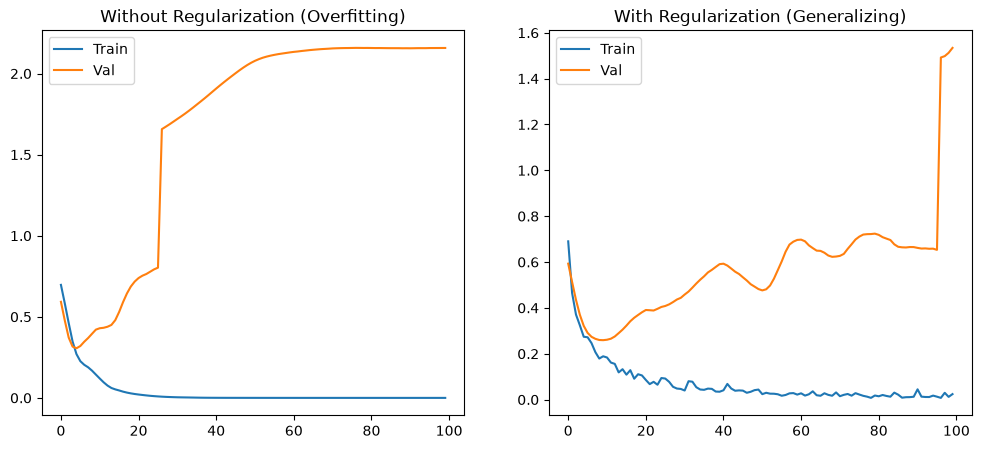

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Setup Data
X, y = make_classification(n_samples=500, n_features=20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = torch.tensor(scaler.fit_transform(X_train), dtype=torch.float32)
X_val = torch.tensor(scaler.transform(X_val), dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
y_val = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)

# 2. Model Architectures
class OverfitNet(nn.Module): # Complex model, no regularization
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(20, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

class RegularizedNet(nn.Module): # Same complexity, but with Dropout and Batch Norm
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(20, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

def train(model, X_train, y_train, X_val, y_val, weight_decay=0):
    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=weight_decay)
    criterion = nn.BCELoss()
    t_losses, v_losses = [], []
    
    for epoch in range(100):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train), y_train)
        loss.backward()
        optimizer.step()
        
        model.eval()
        with torch.no_grad():
            v_loss = criterion(model(X_val), y_val)
            
        t_losses.append(loss.item())
        v_losses.append(v_loss.item())
    return t_losses, v_losses

# Compare
overfit_model = OverfitNet()
reg_model = RegularizedNet()

t_loss_ov, v_loss_ov = train(overfit_model, X_train, y_train, X_val, y_val)
t_loss_reg, v_loss_reg = train(reg_model, X_train, y_train, X_val, y_val, weight_decay=1e-4)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(t_loss_ov, label="Train")
plt.plot(v_loss_ov, label="Val")
plt.title("Without Regularization (Overfitting)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(t_loss_reg, label="Train")
plt.plot(v_loss_reg, label="Val")
plt.title("With Regularization (Generalizing)")
plt.legend()
plt.show()

## 3. Interpretation of Results

**Observation:**
- In the **Without Regularization** plot, you likely see the training loss plummeting while the validation loss either flattens or begins to rise. This is the "Gap" that signals overfitting.
- In the **With Regularization** plot, the training and validation curves stay much closer together.

**Conclusion:**
Regularization (Dropout + Batch Norm + Weight Decay) successfully prevented the model from memorizing the noise. While the training accuracy might be slightly lower than the overfitted model, the **Generalization** is significantly improved, making the model reliable for real-world data.